# Bloomy Knowledge Tracing — Exploratory Data Analysis

Dataset: ASSISTments 2009–2010 Skill Builder (`data/skill_builder_data.csv`). Schema: `docs/data_schema.md`.

Goal: understand the data well enough to trust it before building the baseline P(correct | history) model scoped in `docs/problem_statement.md`. This notebook checks data types, missingness, duplicates, format errors, the problem statement's own stated assumptions (esp. whether the data actually supports "time-ordered history"), categorical distributions, outliers, and class imbalance — in that order, before any relationship/feature analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
data_dir = "../data/skill_builder_data.csv"

In [3]:
# file contains at least one byte sequence that isn't valid UTF-8.
# latin-1 can decode essentially any byte value
df = pd.read_csv(data_dir, encoding="latin-1", low_memory=False)
print(df.shape)
df.head()

(525534, 30)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525534 entries, 0 to 525533
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              525534 non-null  int64  
 1   assignment_id         525534 non-null  int64  
 2   user_id               525534 non-null  int64  
 3   assistment_id         525534 non-null  int64  
 4   problem_id            525534 non-null  int64  
 5   original              525534 non-null  int64  
 6   correct               525534 non-null  int64  
 7   attempt_count         525534 non-null  int64  
 8   ms_first_response     525534 non-null  int64  
 9   tutor_mode            525534 non-null  str    
 10  answer_type           525534 non-null  str    
 11  sequence_id           525534 non-null  int64  
 12  student_class_id      525534 non-null  int64  
 13  position              525534 non-null  int64  
 14  type                  525534 non-null  str    
 15  base_sequen

**Interpretation.** 525,534 rows × 30 columns. Two things stand out against `docs/data_schema.md` before going further:

- `assistment_id` is present in the CSV but is **not documented** on the source site at all — its exact semantics vs. `problem_id` are unconfirmed and should be treated cautiously.
- Every documented `NaN`-bearing column (`skill_id`, `skill_name`, `answer_id`, `answer_text`, `bottom_hint`, `opportunity_original`) shows a *non-null count below 525,534* here, consistent with the schema's claim that these are conditionally populated rather than randomly missing — quantified properly in the Missing Values section below.

## 1. Data inspection — cardinality and unit-of-analysis feasibility

`problem_statement.md` picks **(student, skill)** as the unit of analysis. Before anything else: how many students/skills are there, and how much history does a typical (student, skill) pair actually have to learn from?

In [5]:
id_cols = ["user_id", "skill_id", "problem_id", "assistment_id", "school_id",
           "teacher_id", "assignment_id", "sequence_id", "student_class_id", "template_id"]
print(df[id_cols].nunique())

print("\nRows per student:")
print(df.groupby("user_id").size().describe())

print("\nRows per (student, skill), skill_id non-null only:")
rows_per_pair = df.dropna(subset=["skill_id"]).groupby(["user_id", "skill_id"]).size()
print(rows_per_pair.describe())
print(f"(student, skill) pairs with only 1 attempt: {(rows_per_pair == 1).sum()} / {len(rows_per_pair)} "
      f"= {(rows_per_pair == 1).mean():.1%}")

user_id              4217
skill_id              123
problem_id          26688
assistment_id       17725
school_id              75
teacher_id            153
assignment_id        3521
sequence_id           677
student_class_id      250
template_id           816
dtype: int64

Rows per student:
count    4217.000000
mean      124.622718
std       307.594047
min         1.000000
25%        10.000000
50%        27.000000
75%        95.000000
max      8214.000000
dtype: float64

Rows per (student, skill), skill_id non-null only:


count    41982.000000
mean        10.938212
std         39.757664
min          1.000000
25%          2.000000
50%          5.000000
75%         11.000000
max       3585.000000
dtype: float64
(student, skill) pairs with only 1 attempt: 8379 / 41982 = 20.0%


**Interpretation.** 4,217 students, 123 skills, 26,688 problems, 75 schools, 153 teachers — a mid-sized, multi-school dataset, not a toy set.

Rows per student are heavily right-skewed (mean 124.6, median 27, max 8,214) — a handful of students dominate row count, so any train/test split must be by student, not row, or the model will leak.

The unit-of-analysis check is the important number: across 41,982 (student, skill) pairs, the median pair has only **5** prior attempts and the mean is 10.9, but **19.96% of pairs have exactly 1 attempt** — meaning there's no "history" at all to condition on for roughly 1 in 5 pairs. This is effectively a cold-start problem hiding *inside* the in-scope unit of analysis, even though `problem_statement.md` explicitly places cold-start out of scope for new students. Worth flagging: those single-attempt pairs may need to be excluded from the modeling set (no history → nothing to predict from), which will shrink the usable data further.

- **Student-level**: all of a student's rows pooled together, no matter which of the 123 skills they belong to. 25% of students have ≤10 rows total — thin, but that's spread across possibly dozens of different skills.
- **(Student, skill)-level**: the same student's rows, but now split into one bucket per skill they touched. 25% of pairs have ≤2 rows.

So the drop from "≤10" to "≤2" isn't two independent facts — it's the same history getting diluted. A student with, say, 27 total rows (the median) isn't spending all 27 on one skill; those rows get spread across maybe 5-10 different skills they've worked on. Once you require "history for this specific skill," most of what looked like a reasonable amount of data per student turns out to be only 1-2 prior attempts per skill.

Concretely, this means: the finer you scope the prediction target (down to one specific skill), the more cold-start-like the problem becomes, even for students who otherwise look "warm." A student can have hundreds of interactions overall and still have only 1 prior attempt on the exact skill you're trying to predict their next attempt on.

## 2. Missing values

Counts alone don't say whether a null is a data problem or a structural "not applicable." Cross-tab each null column against the field that governs it.

In [6]:
n_missing = df.isna().sum()
pct_missing = (n_missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": n_missing, "pct_missing": pct_missing})
print(missing_summary[missing_summary["n_missing"] > 0].sort_values("n_missing", ascending=False))

print("\nanswer_id null rate by answer_type (should be ~0 for choose_1/choose_n, ~1 otherwise):")
print(df.assign(answer_id_null=df["answer_id"].isna()).groupby("answer_type")["answer_id_null"].mean())

print("\nbottom_hint null rate by whether any hint was used (hint_count==0):")
print(df.assign(bh_null=df["bottom_hint"].isna(), no_hint=df["hint_count"] == 0)
        .groupby("no_hint")["bh_null"].mean())

print("\nskill_id null rate by original (0=scaffolding, 1=main problem):")
print(df.assign(sk_null=df["skill_id"].isna()).groupby("original")["sk_null"].mean())

                      n_missing  pct_missing
answer_id                476856        90.74
bottom_hint              445627        84.80
answer_text               94784        18.04
skill_name                78690        14.97
opportunity_original      76314        14.52
skill_id                  66326        12.62

answer_id null rate by answer_type (should be ~0 for choose_1/choose_n, ~1 otherwise):
answer_type
algebra          0.999982
choose_1         0.026491
choose_n         0.024322
fill_in_1        1.000000
open_response    1.000000
Name: answer_id_null, dtype: float64

bottom_hint null rate by whether any hint was used (hint_count==0):
no_hint
False    0.000000
True     0.999991
Name: bh_null, dtype: float64

skill_id null rate by original (0=scaffolding, 1=main problem):
original
0    0.658686
1    0.035749
Name: sk_null, dtype: float64


**Interpretation.** Six columns carry nulls: `answer_id` (90.74%), `bottom_hint` (84.80%), `answer_text` (18.04%), `skill_name` (14.97%), `opportunity_original` (14.52%), `skill_id` (12.62%). All six are structural, confirmed by the cross-tabs:

- `answer_id` is ~100% null for `algebra`/`fill_in_1`/`open_response` and ~2.5% null for `choose_1`/`choose_n` — it only exists for multiple-choice items, exactly as documented.
- `bottom_hint` is null for 99.999% of rows where `hint_count == 0` and 0% null otherwise — it's only recorded when a hint was actually requested.
- `skill_id` is null for 65.9% of scaffolding rows (`original == 0`) vs. only 3.6% of main-problem rows (`original == 1`) — scaffolding sub-steps are frequently untagged.

None of this is "missing at random" — mean/median imputation would be wrong here. For the KT model, rows with a null `skill_id` have no target skill and should simply be **excluded**, not imputed (that's ~12.6% of rows, consistent with `opportunity_original`'s null rate, which tracks the same original-problem-only opportunity count).

## 3. Duplicate rows

`docs/data_schema.md` documents that rows are intentionally duplicated once per skill tag on multi-skill problems. Check both that documented pattern and true accidental exact duplicates separately.

In [7]:
print("True exact full-row duplicates:", df.duplicated().sum())

skill_split_cols = ["skill_id", "skill_name", "opportunity", "opportunity_original"]
subset_cols = [c for c in df.columns if c not in skill_split_cols]
n_dup_ignoring_skill = df.duplicated(subset=subset_cols).sum()
print(f"Rows that are duplicates once skill-related columns are ignored: {n_dup_ignoring_skill} "
      f"({n_dup_ignoring_skill / len(df):.1%})")

group_sizes = df.groupby(subset_cols, dropna=False).size()
print("\nDistribution of group sizes (1 = untagged/unique row, >1 = skill-split group):")
print(group_sizes.value_counts().sort_index())

True exact full-row duplicates: 0


Rows that are duplicates once skill-related columns are ignored: 178674 (34.0%)



Distribution of group sizes (1 = untagged/unique row, >1 = skill-split group):
1      296624
2       41079
3        4716
4        1875
5          90
6          21
8          15
9           6
10         46
12         29
14         14
16          7
18         21
19         45
20        189
21         36
22         58
25         67
26        137
27         19
32         21
36         37
37        140
39         39
43        180
44         87
46        391
47        146
60        166
62        175
93        173
97        141
207         6
210        48
213         8
215         8
Name: count, dtype: int64


**Interpretation.** Zero true exact-duplicate rows — no accidental double-logging in this file. But 178,674 rows (34.0%) are duplicates once the skill columns are ignored, confirming the documented skill-split pattern is real and large. Most split-groups are small (41,079 groups of size 2, 4,716 of size 3), but the tail is extreme — some interactions are duplicated **up to 215 times** for 215 different skill tags on a single logged event.

Implication for modeling: naively counting rows as "interactions" overstates real interaction volume for anything not grouped by skill. Any interaction-level feature (e.g. "average time per problem") must first collapse on the non-skill columns, or it will over-weight multi-skill problems by up to 215x.

### 3b. ID-relationship checks

Three loose ends from earlier sections to close out before moving on: what `assistment_id` actually is relative to `problem_id` (flagged as undocumented back in the intro), whether `skill_id` reliably maps to one `skill_name` (it's being used as the primary key), and what's driving the large `(order_id, skill_id)` duplicate count implied by Section 5's `order_id` finding.

In [8]:
# assistment_id vs problem_id
print("unique assistment_id:", df["assistment_id"].nunique(), " | unique problem_id:", df["problem_id"].nunique())
a2p = df.groupby("assistment_id")["problem_id"].nunique()
p2a = df.groupby("problem_id")["assistment_id"].nunique()
print("assistment_ids mapping to >1 problem_id:", (a2p > 1).sum())
print("problem_ids mapping to >1 assistment_id:", (p2a > 1).sum())

# skill_id -> skill_name canonicalization
mapping = df.dropna(subset=["skill_id", "skill_name"]).groupby("skill_id")["skill_name"].nunique()
print("\nskill_ids with more than one distinct skill_name:", (mapping > 1).sum(), "/", len(mapping))

# duplicate (order_id, skill_id) tagging
tagged = df.dropna(subset=["skill_id"])
print("\nduplicate (order_id, skill_id) rows:", tagged.duplicated(subset=["order_id", "skill_id"]).sum())

unique assistment_id: 17725  | unique problem_id: 26688


assistment_ids mapping to >1 problem_id: 2990
problem_ids mapping to >1 assistment_id: 0



skill_ids with more than one distinct skill_name: 0 / 111

duplicate (order_id, skill_id) rows: 121207


**Interpretation.**

- `assistment_id` ↔ `problem_id` is now confirmed **1-to-many**: every `problem_id` belongs to exactly one `assistment_id` (0 counter-examples), but 2,990 `assistment_id`s span more than one `problem_id`. Reading: an "assistment" is the higher-level item/exercise; `problem_id` is the specific instance within it (e.g. a main problem plus its scaffolding steps sharing one `assistment_id`). Update from "unconfirmed" to this working definition.
- `skill_id` → `skill_name` is a clean 1-to-1 mapping — **zero** `skill_id`s map to more than one distinct `skill_name`. Confirms `skill_id` is safe to use as the canonical key with no canonicalization work needed.
- `(order_id, skill_id)` has **121,207 duplicate rows** — at first glance this looks like a new anomaly (the same skill logged twice under the same interaction), but it's explained by Section 5's finding, not a separate problem: since `order_id` is too coarse to disambiguate close-together events, several genuinely distinct attempts on the *same skill* (different `opportunity` values) end up sharing one `order_id` value. This is the same root cause as Section 5, viewed from a different angle — further confirmation that `order_id` cannot be used as a uniqueness or ordering key at fine granularity, but it doesn't threaten row-level integrity (Section 3 already confirmed zero true exact-duplicate rows).

## 4. Format errors

Check categorical fields against the values `docs/data_schema.md` claims are valid, and check a few basic numeric invariants.

In [9]:
for c in ["correct", "original", "tutor_mode", "answer_type", "type", "first_action"]:
    print(f"{c}: {df[c].unique()}")

print("\nInvariant checks:")
print("attempt_count < 1:", (df["attempt_count"] < 1).sum())
print("hint_count > hint_total:", (df["hint_count"] > df["hint_total"]).sum())
print("ms_first_response < 0:", (df["ms_first_response"] < 0).sum())
print("overlap_time < 0:", (df["overlap_time"] < 0).sum())

print("\nattempt_count==0 breakdown by correct:")
print(df.loc[df["attempt_count"] == 0, "correct"].value_counts())

print("\nRows with negative response/overlap time:")
print(df.loc[df["ms_first_response"] < 0,
             ["order_id", "user_id", "ms_first_response", "overlap_time", "attempt_count"]])

correct: [1 0]
original: [1 0]
tutor_mode: <StringArray>
['tutor', 'test']
Length: 2, dtype: str
answer_type: <StringArray>
['algebra', 'fill_in_1', 'choose_1', 'open_response', 'choose_n']
Length: 5, dtype: str
type: <StringArray>
['MasterySection']
Length: 1, dtype: str
first_action: [0 1 2]

Invariant checks:
attempt_count < 1: 22153
hint_count > hint_total: 0
ms_first_response < 0: 8
overlap_time < 0: 11

attempt_count==0 breakdown by correct:
correct
1    12971
0     9182
Name: count, dtype: int64

Rows with negative response/overlap time:
        order_id  user_id  ms_first_response  overlap_time  attempt_count
10859   35397005    79026           -7759575      -7759575              1
111496  29732401    78895            -314441       -314441              1
195498  31272249    70746              -4078         -4078              1
249565  31272249    70746              -4078         -4078              1
313160  31480044    86708            -800125       -758971              6
31317

**Interpretation.**

- `correct` is strictly binary `{0, 1}` in the actual data — the schema's wording ("correct on first attempt / incorrect / asked for help") suggested three states, but "asked for help" is not a distinct value here. Treat the schema's prose as imprecise, not the data.
- `type` has exactly **one** value in this file: `MasterySection`. The schema's `Linear`/`Random`/`Mastery` options describe the full ASSISTments platform, not this skill-builder export — `type` carries zero information here and can be dropped.
- `hint_count > hint_total` never happens (0 rows) — good, that invariant holds.
- `attempt_count < 1` happens on **22,153 rows**, all exactly `0`. These aren't malformed — they're rows where the student asked for a hint without attempting first (`correct` splits 12,971/9,182 for these), so `attempt_count == 0` is a legitimate state, just one worth remembering when using `attempt_count` as a feature (0 doesn't mean "no data," it means "hint before any attempt").
- 8 rows have negative `ms_first_response`/`overlap_time` (min **-7,759,575 ms**, i.e. -129 minutes) — these are true format errors (timers can't run backward) affecting a tiny fraction of rows (0.0015%) and should be dropped or clipped before using timing features.

## 5. Underlying assumptions — is there actually a usable time order?

`docs/data_schema.md` states outright that `order_id` is **"non-chronological."** There is no timestamp column anywhere in this dataset. `problem_statement.md` needs "one student's interaction history up to time *t*" — so before building anything, check concretely whether sorting by `order_id` at least preserves the within-skill attempt sequence (`opportunity` should increase monotonically for a given (student, skill) if `order_id` really tracks time, even loosely).

In [10]:
sub = df.dropna(subset=["skill_id"]).sort_values("order_id")
mono = sub.groupby(["user_id", "skill_id"])["opportunity"].apply(lambda s: s.is_monotonic_increasing)
print(f"(student, skill) groups where opportunity is monotonic non-decreasing when sorted by order_id: "
      f"{mono.mean():.2%}  ({(~mono).sum()} / {len(mono)} groups violate it)")

uid, sid = mono[~mono].index[0]
example = sub[(sub.user_id == uid) & (sub.skill_id == sid)][["order_id", "opportunity", "ms_first_response"]]
print(f"\nExample violation — user_id={uid}, skill_id={sid}:")
print(example)

(student, skill) groups where opportunity is monotonic non-decreasing when sorted by order_id: 98.15%  (776 / 41982 groups violate it)

Example violation — user_id=70740, skill_id=321.0:
        order_id  opportunity  ms_first_response
443531  32072764            2              51531
443530  32072764            1              51531


**Interpretation — this is the most important finding in this notebook.**

Sorting by `order_id` recovers the correct within-skill attempt order for 98.15% of (student, skill) groups, but breaks it for **776 groups (1.85%)**. The example above shows why: two rows share the *exact same* `order_id` (32072764) but have `opportunity` values 1 and 2 — `order_id` doesn't have the resolution to disambiguate events that happen close together, so ties get sorted arbitrarily. This matches the schema's explicit warning that `order_id` is non-chronological.

**Consequence for `problem_statement.md`:** there is no true timestamp in this dataset, so "interaction history up to time *t*" cannot be built from `order_id` directly at the row level. The safe path is to trust `opportunity` (and `opportunity_original`) as the ordering signal *within* a given (student, skill) pair — it's an explicit sequential counter, not inferred from a timestamp — and avoid relying on `order_id` for fine-grained sequencing, especially across skills. This should go in the README's assumptions/limitations section: the model's notion of "history" is opportunity-ordered per skill, not wall-clock time.

## 6. Categorical frequency

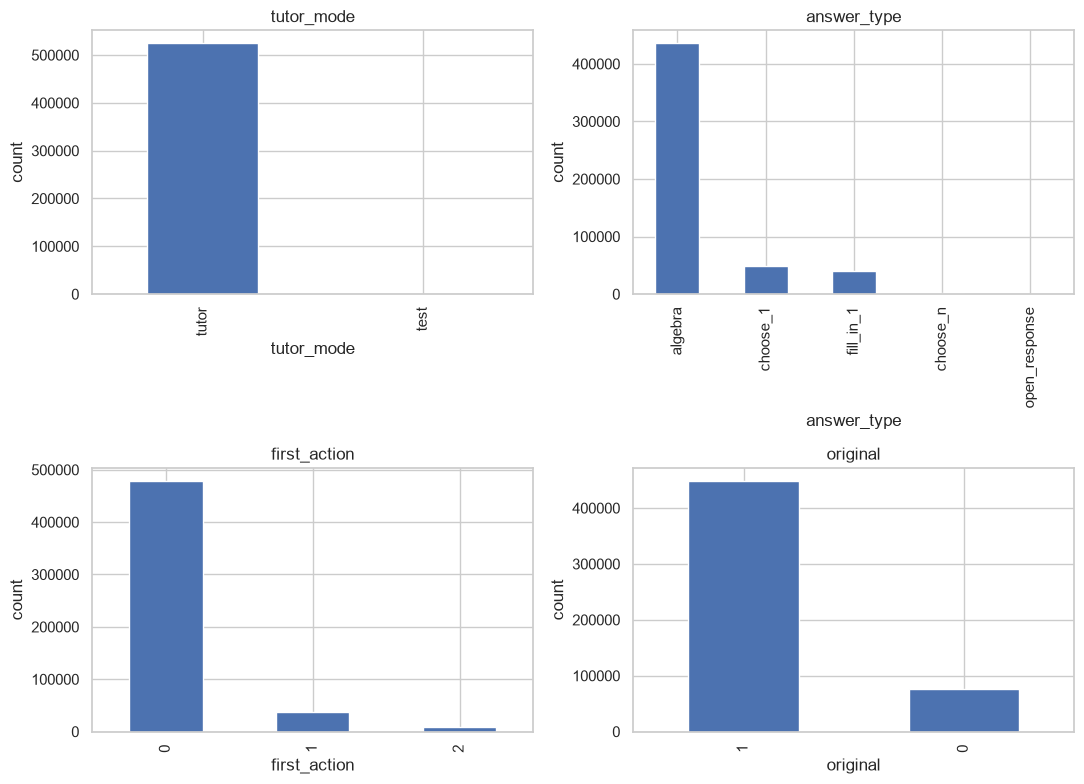


tutor_mode:
tutor_mode
tutor    525201
test        333
Name: count, dtype: int64

answer_type:
answer_type
algebra          436214
choose_1          48923
fill_in_1         39320
choose_n           1069
open_response         8
Name: count, dtype: int64

first_action:
first_action
0    479427
1     37419
2      8688
Name: count, dtype: int64

original:
original
1    449220
0     76314
Name: count, dtype: int64


In [11]:
cat_cols = ["tutor_mode", "answer_type", "first_action", "original"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, c in zip(axes.flat, cat_cols):
    df[c].astype(str).value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(c)
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

for c in cat_cols:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False))

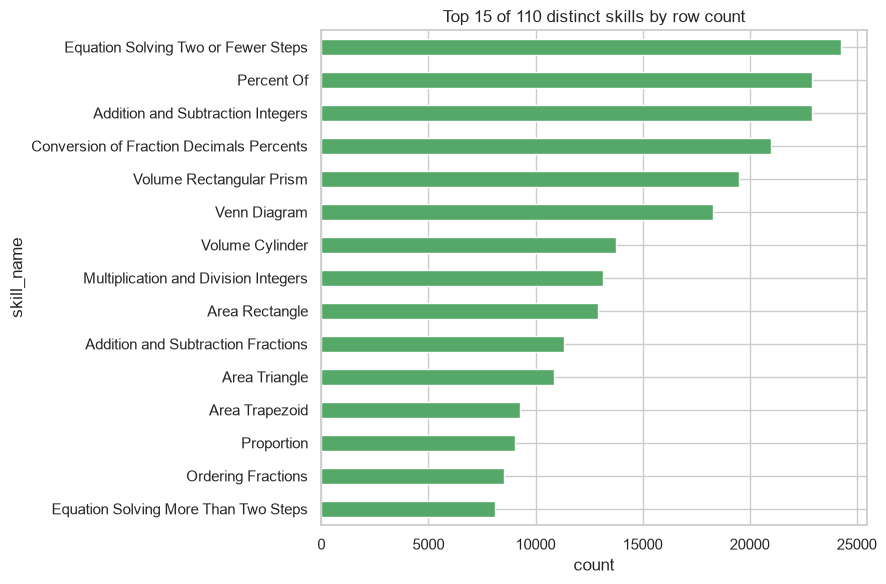

skill_name
Equation Solving Two or Fewer Steps         24253
Percent Of                                  22931
Addition and Subtraction Integers           22895
Conversion of Fraction Decimals Percents    20992
Volume Rectangular Prism                    19489
Venn Diagram                                18275
Volume Cylinder                             13734
Multiplication and Division Integers        13159
Area Rectangle                              12934
Addition and Subtraction Fractions          11334
Area Triangle                               10839
Area Trapezoid                               9288
Proportion                                   9054
Ordering Fractions                           8539
Equation Solving More Than Two Steps         8115
Name: count, dtype: int64


In [12]:
top_skills = df["skill_name"].value_counts().head(15)
plt.figure(figsize=(9, 6))
top_skills.sort_values().plot(kind="barh", color="#55A868")
plt.title(f"Top 15 of {df['skill_name'].nunique()} distinct skills by row count")
plt.xlabel("count")
plt.tight_layout()
plt.show()

print(top_skills)

**Interpretation.**

- `tutor_mode` is almost entirely `tutor` (525,201 rows, 99.94%) vs. `test` (333 rows) — `test` mode is too rare to model separately; likely drop or fold into `tutor`.
- `answer_type` is dominated by `algebra` (436,214, 83.0%), then `choose_1` (48,923), `fill_in_1` (39,320); `choose_n` (1,069) and `open_response` (8) are near-negligible — heavy class imbalance in this feature too, `open_response` is essentially unusable as a standalone category.
- `original` (main vs. scaffolding problem): 449,220 main (85.5%) vs. 76,314 scaffolding (14.5%) — matches the `opportunity_original` null rate from Section 2.
- `first_action`: 0 (attempt) dominates at 479,427 (91.2%), 1 (hint) at 37,419 (7.1%), 2 (unknown third code, undocumented by the schema) at 8,688 (1.7%) — the schema only documents 2 first_action values ("attempt" or "ask for a hint"); value `2` is undocumented and should be checked against the ASSISTments codebook or treated as unknown/other.
- `skill_name` has a long tail typical of curriculum data: 110 distinct skills, top skill ("Equation Solving Two or Fewer Steps") has 24,253 rows, but coverage drops off — worth checking the bottom of the distribution too before assuming every skill has enough data to model.

## 7. Outliers

       ms_first_response  overlap_time  attempt_count     hint_count  \
count       5.255340e+05  5.255340e+05  525534.000000  525534.000000   
mean        4.799217e+04  5.958873e+04       1.502466       0.440900   
std         3.186983e+05  3.424129e+05      10.579588       1.126559   
min        -7.759575e+06 -7.759575e+06       0.000000       0.000000   
25%         7.687000e+03  9.904000e+03       1.000000       0.000000   
50%         2.079100e+04  2.573500e+04       1.000000       0.000000   
75%         5.000000e+04  6.232300e+04       1.000000       0.000000   
max         8.407692e+07  8.407692e+07    3824.000000      10.000000   

          hint_total  
count  525534.000000  
mean        2.343095  
std         1.647155  
min         0.000000  
25%         0.000000  
50%         3.000000  
75%         3.000000  
max        10.000000  


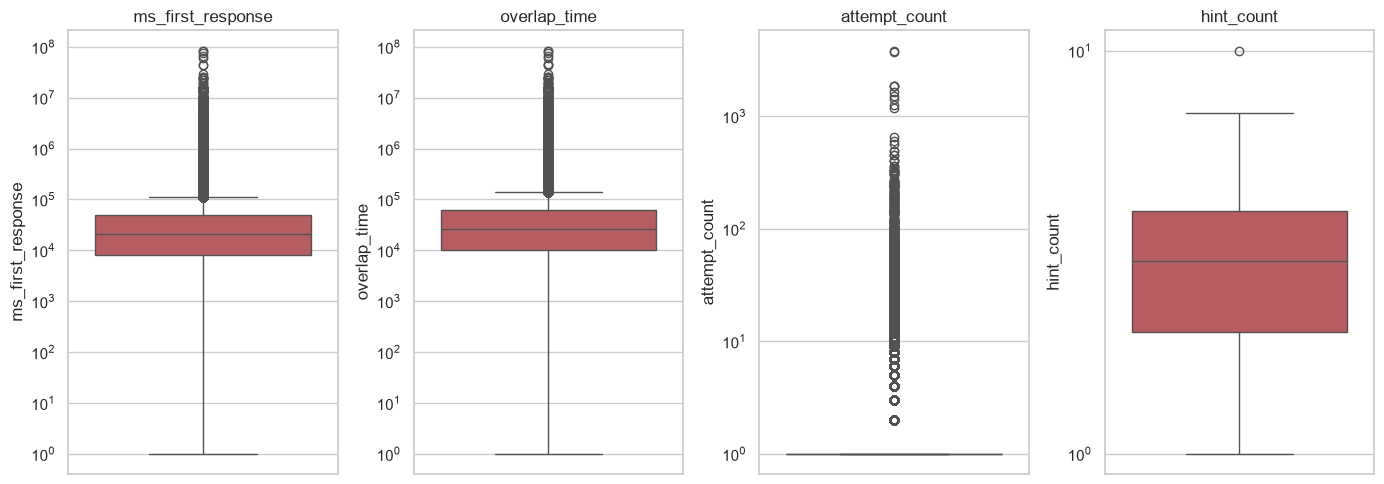


ms_first_response > 5 min: 6544
overlap_time > 10 min: 2723
attempt_count max: 3824  | attempt_count > 20: 1133


In [13]:
numeric_cols = ["ms_first_response", "overlap_time", "attempt_count", "hint_count"]
print(df[numeric_cols + ["hint_total"]].describe())

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14, 5))
for ax, c in zip(axes, numeric_cols):
    positive = df[df[c] > 0][c]
    sns.boxplot(y=positive, ax=ax, color="#C44E52")
    ax.set_yscale("log")
    ax.set_title(c)
plt.tight_layout()
plt.show()

print("\nms_first_response > 5 min:", (df["ms_first_response"] > 300_000).sum())
print("overlap_time > 10 min:", (df["overlap_time"] > 600_000).sum())
print("attempt_count max:", df["attempt_count"].max(), " | attempt_count > 20:", (df["attempt_count"] > 20).sum())

In [14]:
# are ms_first_response and overlap_time redundant?
print("rows where equal:", (df["ms_first_response"] == df["overlap_time"]).sum(), "/", len(df))
print("correlation:", df["ms_first_response"].corr(df["overlap_time"]))
diff = df["overlap_time"] - df["ms_first_response"]
print("rows where overlap_time exceeds ms_first_response by >1s:", (diff > 1000).sum())

rows where equal: 366920 / 525534
correlation: 0.945787061482739
rows where overlap_time exceeds ms_first_response by >1s: 128555


**Interpretation.** All four numeric columns are heavily right-skewed with means far above medians (e.g. `ms_first_response` mean 47,992ms vs. median 20,791ms; `attempt_count` mean 1.50 vs. median 1.0, max **3,824**) — log-scale boxplots were necessary to see the boxes at all.

- 6,544 rows have a first-response time over 5 minutes, 2,723 rows have overlap time over 10 minutes — plausibly real (a student walking away mid-problem), but should be capped/winsorized rather than trusted raw as a numeric feature, since a few multi-hour idle sessions will otherwise dominate any mean-based aggregate.
- `attempt_count` maxes at 3,824 with 1,133 rows above 20 attempts — almost certainly a mix of genuinely stuck students and automated/test accounts; worth a follow-up check on whether extreme-attempt rows cluster on a few `user_id`/`assignment_id` values (test mode, already seen to be rare, is one candidate) before deciding to cap this feature too.
- Combined with the 8 negative-time rows from Section 4, timing columns need explicit outlier handling (clip or winsorize) before use as features — they are not clean out of the box.
- `ms_first_response` and `overlap_time` are highly correlated (r=0.946) but **not the same column**: 69.8% of rows have them exactly equal, but `overlap_time >= ms_first_response` in 128,555 rows by more than a second, sometimes by a lot. Reading: `ms_first_response` is time-to-first-response; `overlap_time` appears to capture fuller elapsed/engaged time on the problem (consistent with multi-attempt rows taking longer overall). They're not interchangeable, but as engineered historical features they'll likely be near-redundant — worth checking multicollinearity before including both.

## 8. Class imbalance

`correct` is the label proxy for "struggle" per `problem_statement.md`'s own stated assumption (struggle ≈ predicted incorrect).

          count     pct
correct                
0        168449  0.3205
1        357085  0.6795


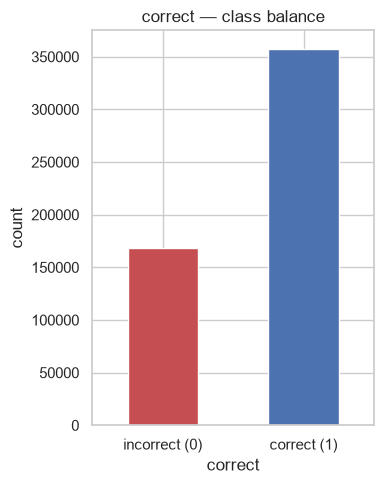

In [15]:
counts = df["correct"].value_counts().sort_index()
pct = df["correct"].value_counts(normalize=True).sort_index()
print(pd.DataFrame({"count": counts, "pct": pct.round(4)}))

plt.figure(figsize=(4, 5))
counts.plot(kind="bar", color=["#C44E52", "#4C72B0"])
plt.xticks([0, 1], ["incorrect (0)", "correct (1)"], rotation=0)
plt.title("correct — class balance")
plt.ylabel("count")
plt.tight_layout()
plt.show()

**Interpretation.** 67.95% correct (357,085) vs. 32.05% incorrect (168,449) — moderate, not severe, imbalance. A trivial "always predict correct" baseline already gets 67.95% accuracy, so accuracy alone is a weak/misleading model metric here; the eventual "Model metric" TODO in `problem_statement.md` should favor something imbalance-aware (AUC, log loss, or precision/recall on the minority "incorrect" class specifically, since that's the class the product actually cares about — predicting *struggle*).

## Summary — what this means for the next steps

- **Data is trustworthy at the row level**: zero true exact duplicates, `hint_count <= hint_total` always holds, and every documented null column is structurally explained (Sections 2–4). A handful of true format errors exist (8–11 negative-time rows) and are small enough to just drop.
- **The (student, skill) unit of analysis is workable but thinner than it looks**: median 5 attempts per pair, but ~20% of pairs have only 1 attempt and can't provide "history" at all (Section 1) — the modeling set should filter these out explicitly, and that filter should be reported, not hidden.
- **The central risk to `problem_statement.md`'s premise**: `order_id` is confirmed non-chronological in 1.85% of (student, skill) groups (Section 5) — there is no real timestamp in this data. `opportunity` (a within-skill sequential counter) is the only safe ordering signal; cross-skill temporal claims are not supportable from this dataset. This belongs in the README's assumptions section, not glossed over.
- **The label is moderately imbalanced** (68/32, Section 8) — plan the model metric around that from the start rather than discovering it after a misleadingly high accuracy number.
- **Scope reminder** (see plan context / `bloomy_project.txt` vs. `problem_statement.md`): this EDA supports the narrower, honest scope — next-attempt P(correct) on a skill already in progress, using a student's own history on that skill — not Bloomy's full forward-looking, knowledge-graph-informed "which skill will they struggle with next" product claim. That gap should be named explicitly in the README, not implied away.

Next: relationship/feature analysis (e.g. does `hint_count`/`attempt_count` history predict next-attempt correctness; does the opportunity-ordered trend within a skill show cross-attempt effects).


For a (student, skill) pair with attempts ordered by opportunity = 1..n: each attempt k ≥ 2 is one training example. Label = correct at opportunity == k. Features = only aggregates over attempts 1..k-1 of that same pair.

In [3]:
import pandas as pd


modeling_data_dir = "../data/processed/modeling_dataset.parquet"

df2 = pd.read_parquet(modeling_data_dir)
df2.head()

,user_id,skill_id,skill_name,opportunity,n_prior_attempts,prior_correct_count,prior_correct_rate,prior_hint_count_mean,prior_attempt_count_mean,prior_ms_first_response_mean,prior_overlap_time_mean,prior_hint_used_rate,original,answer_type,tutor_mode,target_correct,split
0,14,2,Circle Graph,2,1,0,0.000000,2.000000,1.0,10.176259,10.624542,1.000000,1,algebra,tutor,1,train
1,14,2,Circle Graph,3,2,1,0.500000,1.000000,1.0,10.227788,10.451930,0.500000,1,algebra,tutor,0,train
2,14,2,Circle Graph,4,3,1,0.333333,1.333333,1.0,9.995517,10.267545,0.666667,1,algebra,tutor,0,train
3,14,2,Circle Graph,5,4,1,0.250000,1.500000,1.0,9.930434,10.207096,0.750000,1,algebra,tutor,0,train
4,14,2,Circle Graph,6,5,1,0.200000,1.600000,1.0,9.806927,10.143403,0.800000,1,algebra,tutor,0,train


In [5]:
df2.isnull().sum()

user_id                            0
skill_id                           0
skill_name                      9764
opportunity                        0
n_prior_attempts                   0
prior_correct_count                0
prior_correct_rate                 0
prior_hint_count_mean              0
prior_attempt_count_mean           0
prior_ms_first_response_mean       0
prior_overlap_time_mean            0
prior_hint_used_rate               0
original                           0
answer_type                        0
tutor_mode                         0
target_correct                     0
split                              0
dtype: int64